In [24]:
import pandas as pd
df=pd.read_csv('Ice_Cream_Sales_temperatures.csv')

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 2 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Temperature        365 non-null    int64  
 1   Ice Cream Profits  365 non-null    float64
dtypes: float64(1), int64(1)
memory usage: 5.8 KB


In [26]:
df.corr()

,Temperature,Ice Cream Profits
Temperature,1.000000,0.988446
Ice Cream Profits,0.988446,1.000000


In [27]:
df

,Temperature,Ice Cream Profits
0,39,13.17
1,40,11.88
2,41,18.82
3,42,18.65
4,43,17.02
...,...,...
360,99,85.13
361,99,87.08
362,99,89.29
363,101,81.91


Text(0.5, 1.0, 'Temperature Vs. Ice_Cream_Profit')

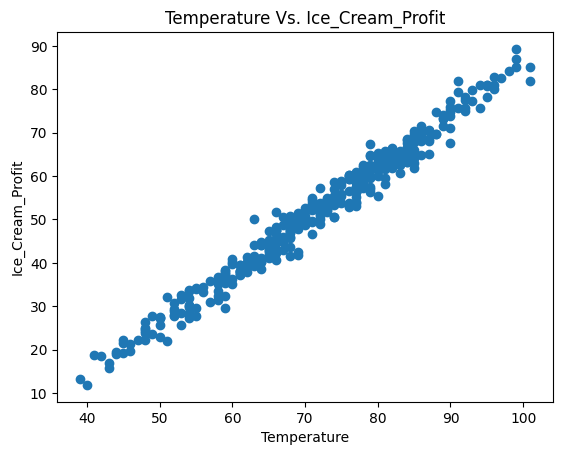

In [28]:
import matplotlib.pyplot as plt 
plt.scatter(df['Temperature'],df['Ice Cream Profits'])
plt.xlabel('Temperature')
plt.ylabel('Ice_Cream_Profit')
plt.title('Temperature Vs. Ice_Cream_Profit')


- The scatter plot shows a strong positive linear relationship between Temperature and Ice Cream Profits, making Linear Regression an appropriate model for this dataset.

In [29]:
from sklearn.linear_model import LinearRegression

Step - 01

We will not give the data directy to the linear model, so first we will segregate input and output

In [30]:
x=df[['Temperature']]
y=df['Ice Cream Profits']

Step - 02

As the LinearRegression is a class, so first we need to create a object so that we can access the methods.

In [31]:
model=LinearRegression()


Next we have to train the model using model.fit(x,y) method.

Syntax

modelname.fit(Xtrain, Ytrain).

It learns the pattern(straight line pattern) from input and output columns.

During the fit method it learns the pattern from the best fit line y=mx+c.

Mostly we use this method for model training.

We must always provide the x value inside df[ [ ] ] is 2D because feature can be more than one so always we must define feature column with [ [ ] ].

In [32]:
model.fit(x,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Step - 03

We have to provide a new input so that it predicts the future output.

Syntax:

model_name.predict( input )

Only accepts input and only one view and it must be 2D always.

We can use predict method only after training the model.

We use it for two scenarios one is prediction and the other is evaluation.

In [33]:
model.predict(x)

array([12.79018223, 13.98219116, 15.17420009, 16.36620901, 17.55821794,
       17.55821794, 18.75022687, 18.75022687, 19.9422358 , 19.9422358 ,
       19.9422358 , 21.13424473, 21.13424473, 22.32625366, 23.51826259,
       23.51826259, 23.51826259, 23.51826259, 23.51826259, 23.51826259,
       24.71027152, 24.71027152, 25.90228045, 25.90228045, 25.90228045,
       25.90228045, 25.90228045, 27.09428938, 27.09428938, 28.2862983 ,
       28.2862983 , 28.2862983 , 28.2862983 , 28.2862983 , 29.47830723,
       29.47830723, 29.47830723, 29.47830723, 30.67031616, 30.67031616,
       30.67031616, 30.67031616, 30.67031616, 30.67031616, 30.67031616,
       30.67031616, 30.67031616, 31.86232509, 31.86232509, 31.86232509,
       31.86232509, 33.05433402, 33.05433402, 34.24634295, 34.24634295,
       35.43835188, 35.43835188, 35.43835188, 35.43835188, 35.43835188,
       35.43835188, 36.63036081, 36.63036081, 36.63036081, 36.63036081,
       36.63036081, 36.63036081, 36.63036081, 36.63036081, 37.82

In [34]:
slope=model.coef_
slope

array([1.19200893])

In [35]:
intercept=model.intercept_
intercept

-33.698166002474984

In [36]:
from sklearn.model_selection import train_test_split
Xtrain,Xtest,Ytrain,Ytest=train_test_split(x,y,random_state=42,train_size=0.8)
Ypred_train=model.predict(Xtrain)

In [37]:
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

- Checking the model performance on Train data(seen data)

In [38]:
print("Train R2 score: ", r2_score(Ytrain,Ypred_train))
print("MAE: ", mean_absolute_error(Ytrain,Ypred_train))
print('RMSE: ', root_mean_squared_error(Ytrain, Ypred_train))

Train R2 score:  0.9746752000208753
MAE:  1.9184234343872824
RMSE:  2.453672143249471


- Checking the model performance on Test data(unseen data)

In [39]:
Ypred_test=model.predict(Xtest)

In [40]:
print("Test R2 score: ", r2_score(Ytest,Ypred_test))
print("MAE: ", mean_absolute_error(Ytest,Ypred_test))
print('RMSE: ', root_mean_squared_error(Ytest, Ypred_test))

Test R2 score:  0.983893379784099
MAE:  1.8339831576127081
RMSE:  2.281485012291047


### The model is a good fit because the training R² score (97.47%) and testing R² score (98.39%) are both very high, and the difference between them is very small (0.92%). This indicates that the model has effectively captured the patterns in the data and generalizes well to unseen data without overfitting.